<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Assignment_12_Intro_to_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


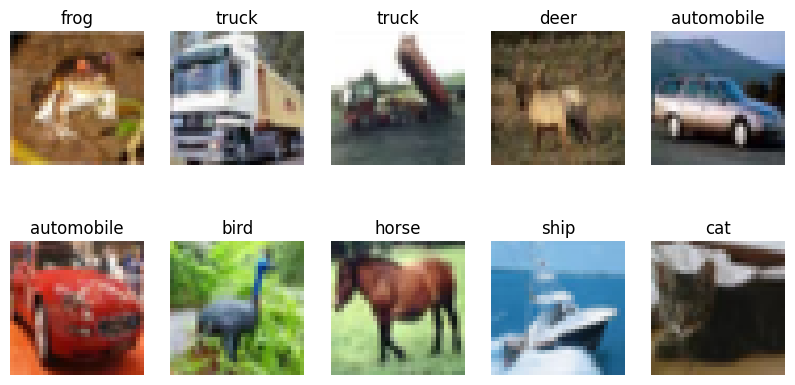

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.3188 - loss: 1.8859 - val_accuracy: 0.3589 - val_loss: 1.7662
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.3909 - loss: 1.6937 - val_accuracy: 0.3942 - val_loss: 1.6894
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4239 - loss: 1.6120 - val_accuracy: 0.4240 - val_loss: 1.6371
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4405 - loss: 1.5633 - val_accuracy: 0.4455 - val_loss: 1.5609
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4622 - loss: 1.5079 - val_accuracy: 0.4484 - val_loss: 1.5483
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4753 - loss: 1.4714 - val_accuracy: 0.4516 - val_loss: 1.5325
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.4830 - loss: 1.4432 - val_accuracy: 0.4788 - val_loss: 1.4969
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.4943 - loss: 1.4165 - 

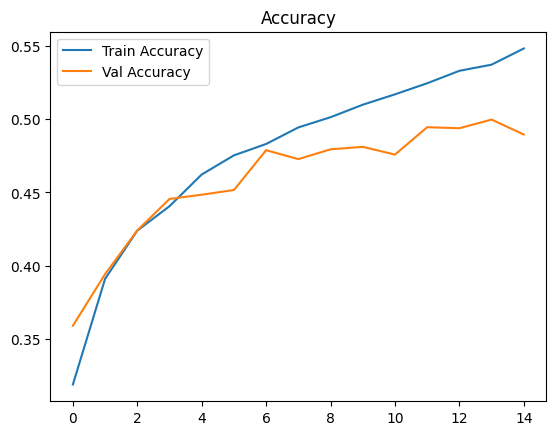

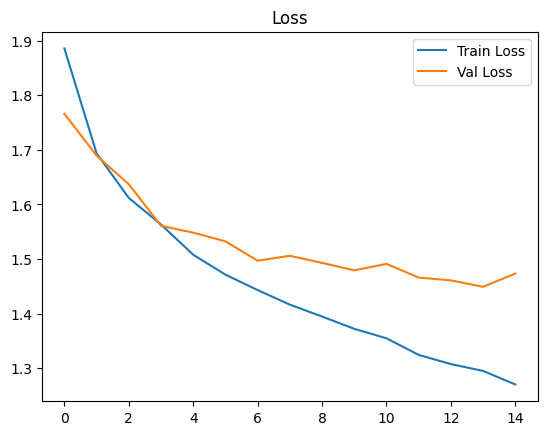

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4881 - loss: 1.4412
Test Accuracy: 0.48809999227523804
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Classification Report:

              precision    recall  f1-score   support

    airplane       0.61      0.51      0.55      1000
  automobile       0.52      0.69      0.60      1000
        bird       0.35      0.39      0.37      1000
         cat       0.36      0.19      0.25      1000
        deer       0.45      0.38      0.41      1000
         dog       0.40      0.41      0.41      1000
        frog       0.47      0.65      0.54      1000
       horse       0.59      0.49      0.54      1000
        ship       0.63      0.60      0.62      1000
       truck       0.49      0.57      0.53      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.48     10000
weighted avg       0.49      0.49      0.48     10000



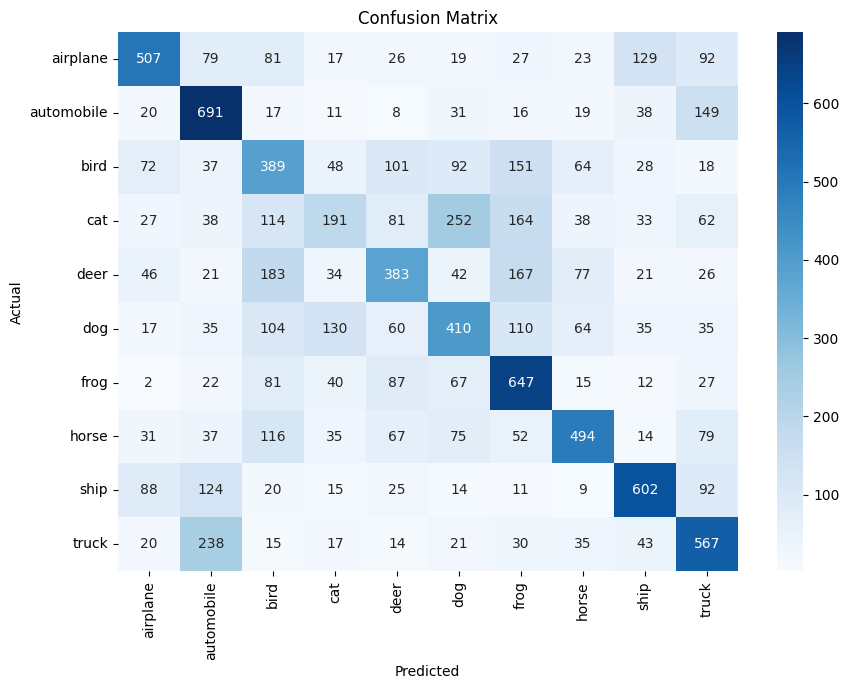

In [1]:
# ================================
# 1. Imports
# ================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ================================
# 2. Load Dataset (CIFAR-10)
# ================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ================================
# 3. Visualize Sample Images
# ================================
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

# ================================
# 4. Preprocessing
# ================================
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten for Feedforward NN
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ================================
# 5. Build Model
# ================================
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# ================================
# 6. Compile Model
# ================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# 7. Train Model
# ================================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# ================================
# 8. Plot Training Results
# ================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

# ================================
# 9. Evaluate Model
# ================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ================================
# 10. Predictions & Metrics
# ================================
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()